In [5]:
import sys
from pathlib import Path

# Путь к корню проекта: ../ от notebooks/
PROJECT_ROOT = Path("..").resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print("Project root:", PROJECT_ROOT)
print("src in path:", any("src" in p for p in sys.path))

Project root: /home/adminlinux/02582_Case2_Group-2
src in path: False


In [6]:
from src.config import DataConfig
from src.data.load_data import load_feature_data

cfg = DataConfig()
loaded = load_feature_data(cfg)

features = loaded.features
meta = loaded.metadata

print(features.shape)
print(meta.shape)
features.head()

(312, 51)
(312, 19)


,HR_TD_Mean,HR_TD_Median,HR_TD_std,HR_TD_Min,HR_TD_Max,HR_TD_AUC,HR_TD_Kurtosis,HR_TD_Skew,HR_TD_Slope_min,HR_TD_Slope_max,...,EDA_TD_T_AUC,EDA_TD_T_Kurtosis,EDA_TD_T_Skew,EDA_TD_T_Slope_min,EDA_TD_T_Slope_max,EDA_TD_T_Slope_mean,EDA_TD_T_Slope,EDA_TD_P_Peaks,EDA_TD_P_RT,EDA_TD_P_ReT
0,78.663878,76.70,7.480043,67.25,92.48,23048.450,-1.091448,0.369955,-0.7300,0.9775,...,213.374114,1.345997,-1.379434,-0.000144,0.000138,0.000010,1.036040e-05,11,2.522727,2.075000
1,76.540732,76.61,2.584756,69.82,82.33,23959.920,-0.245338,0.338732,-0.3600,0.1900,...,213.235380,0.887010,0.854067,-0.000146,0.000165,0.000009,7.714503e-06,15,2.214286,2.192308
2,78.173563,77.92,2.681255,72.22,82.80,20324.605,-0.615922,-0.233047,-0.6300,0.3575,...,173.465157,0.205817,0.480581,-0.000112,0.000132,0.000002,1.799914e-06,10,1.972222,2.111111
3,83.073688,83.88,7.363598,69.42,96.12,24924.300,-0.866610,-0.046021,-0.4650,0.6500,...,191.943390,2.488339,1.246665,-0.000455,0.000481,-0.000001,-1.355151e-07,12,1.886364,1.805556
4,72.281250,72.91,3.193762,64.95,79.98,23052.100,0.200401,-0.560948,-0.3725,0.3375,...,192.341180,1.196508,1.592099,-0.000420,0.000334,0.000014,1.267198e-05,20,1.812500,1.926471


In [7]:
meta.head()

,Round,Phase,Individual,Puzzler,original_ID,raw_data_path,Team_ID,Cohort,Frustrated,upset,hostile,alert,ashamed,inspired,nervous,attentive,afraid,active,determined
0,round_3,phase3,1,1,19.0,dataset/D1_4/ID_1/round_3/phase3,D1_4_Team10,D1_4,2.0,1.0,1.0,2.0,1.0,2.0,2.0,3.0,1.0,2.0,2.0
1,round_3,phase2,1,1,19.0,dataset/D1_4/ID_1/round_3/phase2,D1_4_Team10,D1_4,3.0,2.0,1.0,3.0,2.0,2.0,2.0,3.0,1.0,3.0,3.0
2,round_3,phase1,1,1,19.0,dataset/D1_4/ID_1/round_3/phase1,D1_4_Team10,D1_4,2.0,1.0,1.0,2.0,1.0,3.0,2.0,3.0,2.0,3.0,3.0
3,round_2,phase3,1,1,19.0,dataset/D1_4/ID_1/round_2/phase3,D1_4_Team10,D1_4,2.0,1.0,1.0,2.0,1.0,3.0,2.0,3.0,2.0,3.0,3.0
4,round_2,phase2,1,1,19.0,dataset/D1_4/ID_1/round_2/phase2,D1_4_Team10,D1_4,2.0,3.0,1.0,3.0,2.0,3.0,3.0,4.0,2.0,4.0,4.0


In [8]:
features.isna().sum().sort_values(ascending=False).head(15)

EDA_TD_P_RT         1
EDA_TD_P_ReT        1
HR_TD_Mean          0
HR_TD_Min           0
HR_TD_Max           0
HR_TD_AUC           0
HR_TD_Kurtosis      0
HR_TD_Skew          0
HR_TD_Slope_min     0
HR_TD_Slope_max     0
HR_TD_Slope_mean    0
HR_TD_Slope         0
TEMP_TD_Mean        0
TEMP_TD_Median      0
TEMP_TD_std         0
dtype: int64

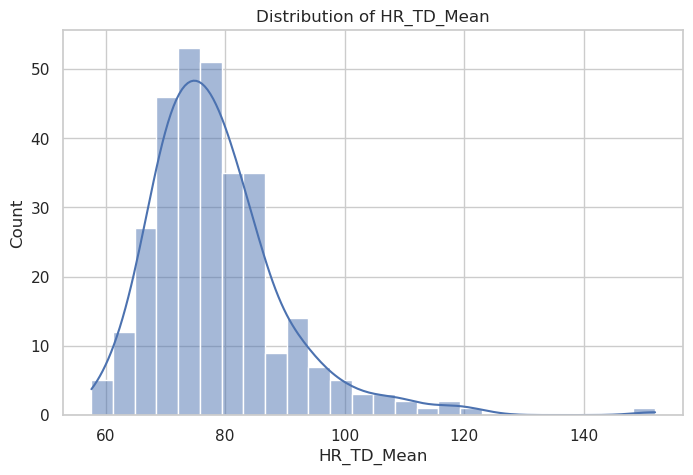

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid", context="notebook")
plt.figure(figsize=(8, 5))
sns.histplot(features["HR_TD_Mean"], kde=True)
plt.title("Distribution of HR_TD_Mean")
plt.show()

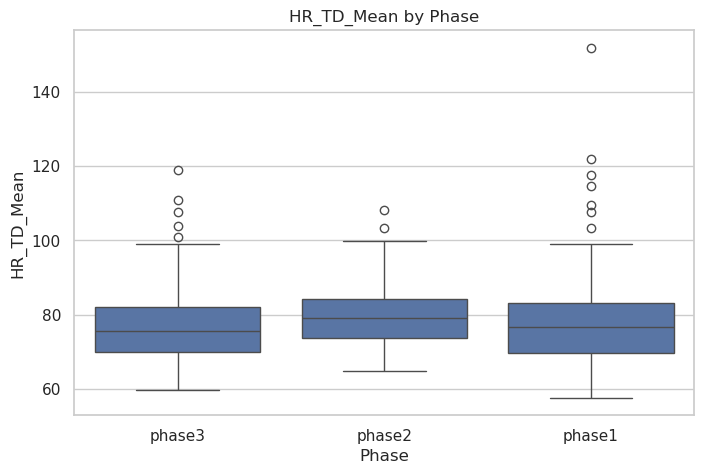

In [10]:
eda_df = features.join(meta["Phase"])

plt.figure(figsize=(8, 5))
sns.boxplot(data=eda_df, x="Phase", y="HR_TD_Mean")
plt.title("HR_TD_Mean by Phase")
plt.show()

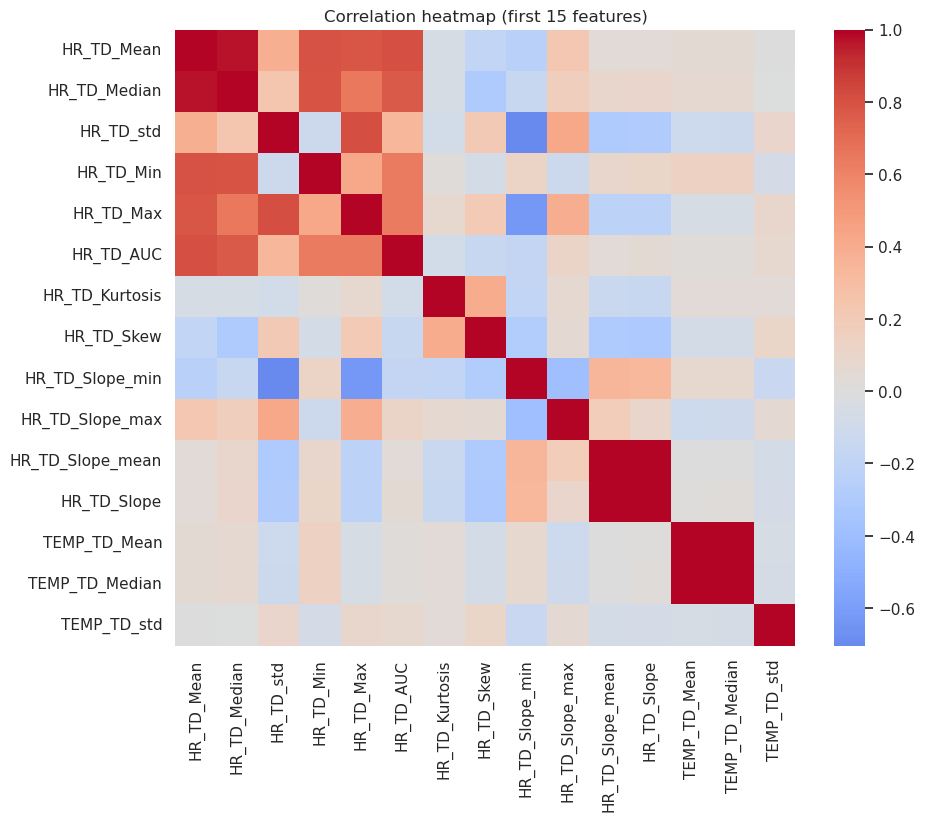

In [11]:
corr = features.iloc[:, :15].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, cmap="coolwarm", center=0)
plt.title("Correlation heatmap (first 15 features)")
plt.show()

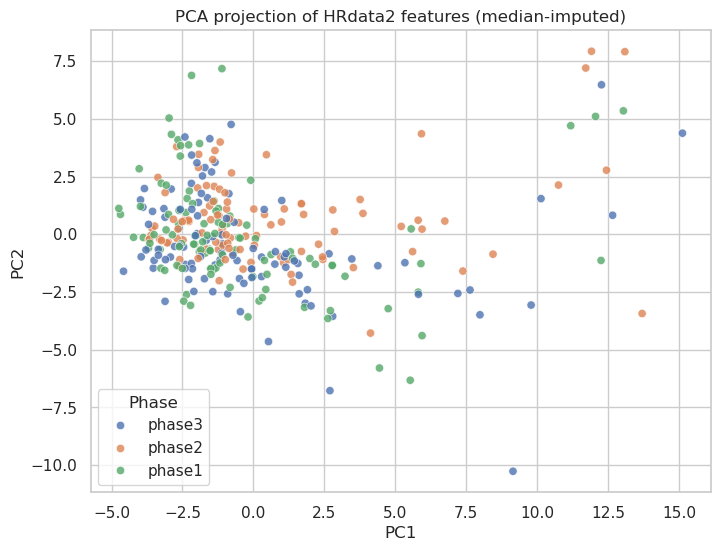

In [13]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# Импутируем пропуски медианой, чтобы PCA не падал
features_imputed = features.fillna(features.median())

X_scaled = StandardScaler().fit_transform(features_imputed)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

pca_df = meta[["Phase"]].copy()
pca_df["PC1"] = X_pca[:, 0]
pca_df["PC2"] = X_pca[:, 1]

plt.figure(figsize=(8, 6))
sns.scatterplot(data=pca_df, x="PC1", y="PC2", hue="Phase", alpha=0.8)
plt.title("PCA projection of HRdata2 features (median-imputed)")
plt.show()